In [45]:
import time
import os
import sys

import torch
from model.lanenet.train_lanenet import train_model
from dataloader.data_loaders import TusimpleSet
from dataloader.transformers import Rescale
from model.lanenet.LaneNet import LaneNet
from torch.utils.data import DataLoader
from torch.autograd import Variable
from PIL import Image
from torchvision import transforms
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except ImportError:
    A = None
    ToTensorV2 = None

from model.utils.cli_helper import parse_args
from model.eval_function import Eval_Score
import sys
import numpy as np
import pandas as pd
import cv2
from matplotlib import pyplot as plt


DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(DEVICE)
from scipy.ndimage import binary_dilation, label
from matplotlib.patches import Patch


cpu


Use ENet as backbone
Test Image Shape: (1280, 720)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.6399999].


torch.Size([512, 256, 3])
<class 'torch.Tensor'>


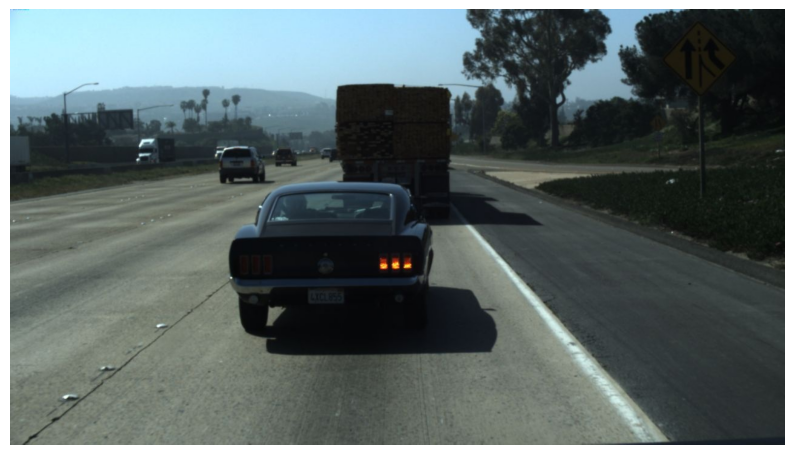

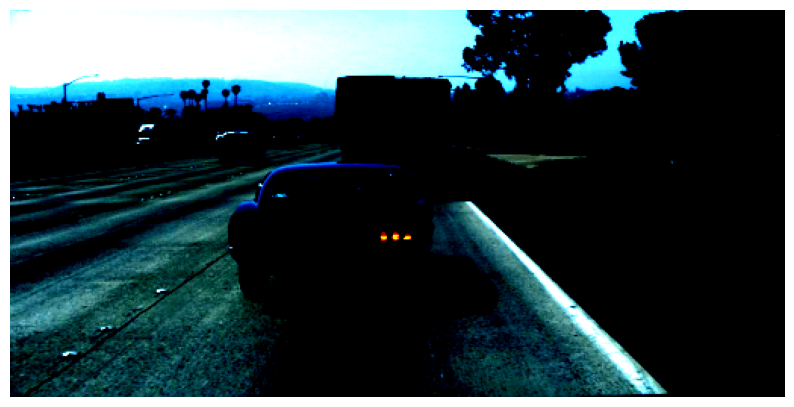

In [20]:
model = LaneNet(arch="ENet")
weights = torch.load("/Users/amannindra/Projects/Autonomous-Bicycle/LaneNet/lanenet-lane-detection-pytorch/trained_models/best_model.pth", map_location=torch.device('cpu'), weights_only=True)

model.load_state_dict(weights)

image_file = "/Users/amannindra/Projects/Autonomous-Bicycle/LaneNet/TUSimple/train_set/training/gt_image/0003.png"

test_image = Image.open(image_file)
print(f"Test Image Shape: {test_image.size}")
transform = A.Compose([
      A.Resize(height=256, width=512),
      A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
      ToTensorV2(),
])


def load_test_data(img,transform):
    test_image = Image.open(img).convert("RGB")
    img = transform(image=np.array(test_image))['image']
    return img

def visualize(image):
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(image)

visualize(test_image)
augmented_image = transform(image=np.array(test_image))['image'].T
print(augmented_image.shape)
print(type(augmented_image))
visualize(augmented_image.permute(1, 0, 2).numpy())


In [21]:
model.eval()
model.to(DEVICE)


LaneNet(
  (_encoder): ENet_Encoder(
    (initial_block): InitialBlock(
      (conv): Sequential(
        (0): Conv2d(3, 13, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(13, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
      )
      (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (bottleneck1_0): BottleneckModule(
      (activate): PReLU(num_parameters=1)
      (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (conv): Sequential(
        (0): Conv2d(16, 64, kernel_size=(2, 2), stride=(2, 2))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): PReLU(num_p

In [22]:

def frame(model, dummy_input, frame):
    # dummy_input = load_test_data(image_file, transform).to(DEVICE)
    # orig = np.array(Image.open(image_file).convert("RGB"))
    
    orig_h, orig_w = frame.shape[:2]
    

    dummy_input = torch.unsqueeze(dummy_input, dim=0)
    with torch.no_grad():
        outputs = model(dummy_input)
        
    
    print(outputs.keys())
    print(f"binary_seg_logits: {outputs['binary_seg_logits'].shape}")
    print(f"instance_seg_logits: {outputs['instance_seg_logits'].shape}")
    print(f"binary_seg_pred: {outputs['binary_seg_pred'].shape}")

    # print(outputs["binary_seg_logits"])
    
    instanc_pred = torch.squeeze(outputs['instance_seg_logits'].detach().to('cpu')).numpy() * 255
    binary_pred = torch.squeeze(outputs['binary_seg_pred']).to('cpu').numpy().astype(np.uint8)

    pred_mask_orig = cv2.resize(binary_pred, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)


    lane_components, num_lanes = label(pred_mask_orig == 1)
    # print(lane_components)
    component_sizes = np.bincount(lane_components.ravel())
    component_ids = np.arange(1, len(component_sizes))
    component_ids = component_ids[component_sizes[component_ids] > 200]
    component_ids = sorted(component_ids, key=lambda lane_id: component_sizes[lane_id], reverse=True)
    
    print(instanc_pred)

    lane_colors = np.array([
        [255, 0, 0],      # red
        [0, 255, 0],      # green
        [0, 128, 255],    # blue/orange-ish in RGB display
        [255, 255, 0],    # yellow
        [255, 0, 255],    # magenta
        [0, 255, 255],    # cyan
        [0, 255, 128],
        [0, 128, 128],
        [128, 255, 255],
        [128, 128, 128],
    ], dtype=np.uint8)

    # overlay = frame.copy()
    # legend_handles = []

    # for lane_index, component_id in enumerate(component_ids[:len(lane_colors)]):
    #     lane_mask = binary_dilation(lane_components == component_id, iterations=2)
    #     color = lane_colors[lane_index]
    #     overlay[lane_mask] = color
    #     legend_handles.append(
    #         Patch(
    #             facecolor=color / 255.0,
    #             edgecolor='black',
    #             label=f'Lane {lane_index + 1}',
    #         )
    #     )



    # # print(type(ove/rlay))
    # blended = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)
    # return blended

    # plt.figure(figsize=(14, 8))
    # plt.imshow(blended)
    # if legend_handles:
    #     plt.legend(handles=legend_handles, loc='lower right')
    # plt.axis("off")
    # plt.show()
    
LANE_COLORS = np.array([
    [255, 0, 0],      # red
    [0, 255, 0],      # green
    [0, 128, 255],    # blue/orange-ish in RGB display
    [255, 255, 0],    # yellow
    [255, 0, 255],    # magenta
    [0, 255, 255],    # cyan
    [0, 255, 128],
    [0, 128, 128],
    [128, 255, 255],
    [128, 128, 128],
], dtype=np.uint8)


def _extract_instance_embedding(outputs):
    embedding = outputs.get('instance_embedding')
    if embedding is None:
        embedding = outputs['instance_seg_logits']
    return embedding.detach().to('cpu')[0].numpy().astype(np.float32)


def _mean_shift_center(embeddings, center, bandwidth, max_iters):
    center = center.astype(np.float32, copy=True)

    for _ in range(max_iters):
        distances = np.linalg.norm(embeddings - center, axis=1)
        neighbors = embeddings[distances <= bandwidth]
        if len(neighbors) == 0:
            break

        next_center = np.mean(neighbors, axis=0)
        if np.linalg.norm(next_center - center) < 1e-3:
            center = next_center
            break
        center = next_center

    return center


def cluster_lane_embeddings(binary_pred, instance_embedding, delta_v=0.5,
                            min_cluster_size=50, max_lanes=10,
                            mean_shift_iters=10):
    lane_mask = binary_pred == 1
    cluster_labels = np.zeros(binary_pred.shape, dtype=np.int32)
    if not np.any(lane_mask):
        return cluster_labels

    if instance_embedding.shape[1:] != binary_pred.shape:
        raise ValueError(
            "Instance embedding shape {} does not match binary mask shape {}".format(
                instance_embedding.shape,
                binary_pred.shape,
            )
        )

    lane_ys, lane_xs = np.where(lane_mask)
    lane_embeddings = instance_embedding[:, lane_ys, lane_xs].T
    remaining = np.ones(lane_embeddings.shape[0], dtype=bool)

    radius = 2.0 * delta_v
    rng = np.random.default_rng(0)
    cluster_id = 1

    while np.any(remaining) and cluster_id <= max_lanes:
        remaining_indices = np.flatnonzero(remaining)
        seed_index = rng.choice(remaining_indices)
        center = _mean_shift_center(
            lane_embeddings[remaining],
            lane_embeddings[seed_index],
            radius,
            mean_shift_iters,
        )

        distances = np.linalg.norm(lane_embeddings - center, axis=1)
        cluster = (distances <= radius) & remaining

        if np.count_nonzero(cluster) < min_cluster_size:
            if np.any(cluster):
                remaining[cluster] = False
            else:
                remaining[seed_index] = False
            continue

        cluster_labels[lane_ys[cluster], lane_xs[cluster]] = cluster_id
        remaining[cluster] = False
        cluster_id += 1

    return cluster_labels


def draw_lane_clusters(frame, cluster_labels, colors=LANE_COLORS):
    orig_h, orig_w = frame.shape[:2]
    cluster_labels_orig = cv2.resize(
        cluster_labels.astype(np.int32),
        (orig_w, orig_h),
        interpolation=cv2.INTER_NEAREST,
    )

    overlay = frame.copy()
    lane_ids = [lane_id for lane_id in np.unique(cluster_labels_orig) if lane_id != 0]

    for lane_index, lane_id in enumerate(lane_ids[:len(colors)]):
        lane_mask = binary_dilation(cluster_labels_orig == lane_id, iterations=2)
        overlay[lane_mask] = colors[lane_index]

    return cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)


def frame2(model, dummy_input, frame, DEVICE, delta_v=0.5,
          min_cluster_size=50, max_lanes=10, mean_shift_iters=10):
    # dummy_input = load_test_data(image_file, transform).to(DEVICE)
    # orig = np.array(Image.open(image_file).convert("RGB"))

    dummy_input = torch.unsqueeze(dummy_input, dim=0).to(DEVICE)
    with torch.no_grad():
        outputs = model(dummy_input)

    binary_pred = torch.squeeze(outputs['binary_seg_pred']).to('cpu').numpy().astype(np.uint8)
    instance_embedding = _extract_instance_embedding(outputs)
    cluster_labels = cluster_lane_embeddings(
        binary_pred,
        instance_embedding,
        delta_v=delta_v,
        min_cluster_size=min_cluster_size,
        max_lanes=max_lanes,
        mean_shift_iters=mean_shift_iters,
    )

    return draw_lane_clusters(frame, cluster_labels)
    
def load_test_data_2(img,transform):
    img = transform(image=np.array(img))['image']
    return img



video_cap = cv2.VideoCapture("/Users/amannindra/Projects/Autonomous-Bicycle/Send/numpy_videos/2minHalfdome.mp4")


count, success = 0, True
fps = video_cap.get(cv2.CAP_PROP_FPS)
print(f"FPB: {fps}")
width = video_cap.get(cv2.CAP_PROP_FRAME_WIDTH)
print(f"Width: {width}")
height = video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
print(f"height: {height}")



# output_video = "2minHalfdome_model.mp4"
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# video_writer = cv2.VideoWriter(output_video, fourcc, fps, (int(width), int(height)))

# while success:
#     success, image = video_cap.read() # Read frame
    
#     if success:  
#         img = transform(image=np.array(image))['image']
#         orig = np.array(image)
#         new_frame = frame(model, img, orig)
#         count += 1
#         video_writer.write(new_frame)
#     count += 1
#     if (count == 30):
#         break
    
    
    
# video_writer.release()


# print("Video successfully generated!")

dummy_input = load_test_data(image_file, transform).to(DEVICE)
orig = np.array(Image.open(image_file).convert("RGB"))
frame(model,dummy_input, orig)
 

FPB: 60.0
Width: 1920.0
height: 1080.0
dict_keys(['instance_seg_logits', 'binary_seg_pred', 'binary_seg_logits'])
binary_seg_logits: torch.Size([1, 2, 256, 512])
instance_seg_logits: torch.Size([1, 3, 256, 512])
binary_seg_pred: torch.Size([1, 1, 256, 512])
[[[2.5436069e+02 2.5432167e+02 2.5411798e+02 ... 2.5349483e+02
   2.5295860e+02 2.5410910e+02]
  [2.5439424e+02 2.5319508e+02 2.5438721e+02 ... 2.5256619e+02
   2.5348363e+02 2.5322618e+02]
  [2.5452345e+02 2.5454968e+02 2.5419818e+02 ... 2.5378874e+02
   2.5346716e+02 2.5357675e+02]
  ...
  [2.0135672e+00 4.8853847e-01 1.7348000e-01 ... 2.5357103e+02
   2.5401720e+02 2.5411340e+02]
  [1.0056469e+00 1.8614188e+00 1.2854230e-01 ... 2.5335062e+02
   2.5309618e+02 2.5369107e+02]
  [2.7565310e+00 1.3228407e+00 7.2686309e-01 ... 2.5245868e+02
   2.5282477e+02 2.5341327e+02]]

 [[1.4277748e+00 2.3032374e+00 2.1795318e+00 ... 7.5643820e-01
   9.3657351e-01 5.2955323e-01]
  [1.2546269e+00 7.0926237e-01 1.2570850e+00 ... 4.4765720e-01
   3.7

In [23]:
!pip freeze | grep opencv

opencv-python-headless==4.13.0.92


In [24]:
!pip uninstall opencv-python

In [25]:
!which pip


/Users/amannindra/miniconda3/envs/Lannet310/bin/pip


In [33]:
from pathlib import Path

file = Path("home/outputVideos/debug_raw_epoche030.mp4")

num = 1
dir_path = file.parent
print(dir_path)

print(file.stem)

print(file)

home/outputVideos
debug_raw_epoche030
home/outputVideos/debug_raw_epoche030.mp4


In [34]:
file.suffix

'.mp4'

In [10]:

import time
import os
import sys

import torch
from model.lanenet.train_lanenet import train_model
from dataloader.data_loaders import TusimpleSet
from dataloader.transformers import Rescale
from model.lanenet.LaneNet import LaneNet
from torch.utils.data import DataLoader
from torch.autograd import Variable
from PIL import Image
from torchvision import transforms
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except ImportError:
    A = None
    ToTensorV2 = None

from model.utils.cli_helper import parse_args
from model.eval_function import Eval_Score
import sys
import numpy as np
import pandas as pd
import cv2
from matplotlib import pyplot as plt
from model.lanenet.backbone.H_Net import H_Net, build_H
from lane_utils import (
    cluster_lane_embeddings,
    fit_lane_polynomials,
    draw_lane_clusters,
    draw_all_lane_curves,
)

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(DEVICE)
from scipy.ndimage import binary_dilation, label
from matplotlib.patches import Patch


def _load_weights(model, path, device):
    print(path)
    try:
        w = torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        w = torch.load(path, map_location=device)
    model.load_state_dict(w)

cpu


In [7]:
Lanenet = LaneNet(arch="ENet")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
_load_weights(Lanenet, "trained_models/LaneNewTrained.pth", device)
Lanenet.eval().to(device)

hnet = H_Net()
_load_weights(hnet, "trained_models/hnet_best.pth",device)
hnet.eval().to(device)

Use ENet as backbone
trained_models/LaneNewTrained.pth
trained_models/hnet_best.pth


H_Net(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (4): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inpl

In [57]:
lane_tf = A.Compose([
        A.Resize(256, 512),
        A.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ToTensorV2(),
])

hnet_tf = A.Compose([
        A.Resize(64, 128),
        A.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ToTensorV2(),
]) if hnet else None

In [56]:
cap = cv2.VideoCapture("/Users/amannindra/Projects/Autonomous-Bicycle/HybridNets/demo/video/1.mp4")
def process_frame(lanenet, hnet, input_tensor, hnet_tensor, frame_bgr, device):
    # LaneNet forward
    with torch.no_grad():
        outputs = lanenet(torch.unsqueeze(input_tensor, 0).to(device))
        params = hnet(torch.unsqueeze(hnet_tensor, 0).to(device))
        
    binary_pred = outputs["binary_seg_pred"].cpu().numpy().astype(np.uint8)
    binary_pred = outputs["binary_seg_pred"][0, 0].cpu().numpy().astype(np.uint8)
    instance_embedding = outputs["instance_embedding"]
    instance_seg_logits = outputs["instance_seg_logits"]
    
    mask_frame = binary_pred * 255
    mask_bgr = cv2.cvtColor(mask_frame, cv2.COLOR_GRAY2BGR)
    return mask_bgr
    
    
    # print(f"instance_embedding: {instance_embedding}")
    # print(f"instance_seg_logits: {instance_seg_logits}")
    
    # H = build_H(params)[0] 
    # print(H)
    
    # if args.binary_threshold is not None:
    #     lane_prob = torch.softmax(outputs["binary_seg_logits"], dim=1)[0, 1]
    #     binary_pred = (lane_prob > args.binary_threshold).detach().cpu().numpy().astype(np.uint8)
    # else:
    #     binary_pred = outputs["binary_seg_pred"][0, 0].detach().cpu().numpy().astype(np.uint8)
    # embedding   = _extract_embedding(outputs, args.embedding_activation)

    # cluster_labels = cluster_lane_embeddings(
    #     binary_pred, embedding,
    #     delta_v=args.delta_v, cluster_radius=args.cluster_radius,
    #     mean_shift_bandwidth=args.mean_shift_bandwidth,
    #     mean_shift_iters=args.mean_shift_iters,
    #     min_cluster_size=args.min_cluster_size, max_lanes=args.max_lanes,
    # )

    # n_clusters = len([l for l in np.unique(cluster_labels) if l != 0])

    # H = None
    # if hnet is not None:
    #     with torch.no_grad():
    #         params = hnet(torch.unsqueeze(hnet_tensor, 0).to(device))
    #     H = build_H(params)[0]

    # polys, curves_norm = {}, {}
    # if hnet is not None or args.debug:
    #     polys, _, curves_norm = fit_lane_polynomials(
    #         cluster_labels, H, args.width, args.height, args.hnet_poly_order)

    # if hnet is None:
    #     out = draw_lane_clusters(frame_bgr, cluster_labels, args.dilation_iters)
    # else:
    #     out = draw_all_lane_curves(frame_bgr, curves_norm, args.hnet_curve_thickness)

    # if args.debug:
    #     info_lines = [
    #         "lane px:        {}".format(int(np.count_nonzero(binary_pred))),
    #         "clusters found: {}".format(n_clusters),
    #         "polys fit:      {}".format(len(polys)),
    #         "dropped:        {}".format(n_clusters - len(polys)),
    #     ]
    #     bev = None
    #     if H is not None:
    #         Hn = H.detach().cpu().numpy()
    #         bev = warp_to_bev(frame_bgr, Hn)
    #         info_lines += ["H = [{:+.2f} {:+.2f} {:+.2f}]".format(*Hn[0]),
    #                        "    [{:+.2f} {:+.2f} {:+.2f}]".format(*Hn[1]),
    #                        "    [{:+.2f} {:+.2f} {:+.2f}]".format(*Hn[2]),
    #                        "(identity = 1,0,0 / 0,1,0 / 0,0,1)"]
    #     else:
    #         info_lines.append("H-Net: off")
    #     out = make_debug_composite(frame_bgr, binary_pred, cluster_labels,
    #                                out, info_lines, bev_frame=bev)

    # return out, cluster_labels
fps  = cap.get(cv2.CAP_PROP_FPS)
writer = cv2.VideoWriter("outputVideos/testing.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (512, 256))

i = 0
while True:
    ok, bgr = cap.read()
    if not ok:
        break
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    lt  = lane_tf(image=rgb)["image"]
    ht  = hnet_tf(image=rgb)["image"]
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 20))
    # ax1.imshow(lt)
    # ax1.axis('off') 
    # ax2.imshow(ht)
    # ax2.axis('off') 
    mask = process_frame(Lanenet, hnet, lt, ht, rgb, device)
    writer.write(mask)
    i += 1
cap.release()
writer.release()

    

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

In [49]:
s = np.ones((256,512))
s.shape

(256, 512)

In [50]:
s = s * 256

s.shape

print(s)

[[256. 256. 256. ... 256. 256. 256.]
 [256. 256. 256. ... 256. 256. 256.]
 [256. 256. 256. ... 256. 256. 256.]
 ...
 [256. 256. 256. ... 256. 256. 256.]
 [256. 256. 256. ... 256. 256. 256.]
 [256. 256. 256. ... 256. 256. 256.]]
